In [4]:
import pandas as pd
import psycopg2
import matplotlib.pyplot as plt

conn = psycopg2.connect(
    dbname="movies",
    user="postgres",
    password="070401",
    host="localhost",
    port="5432"
)

df = pd.read_sql("SELECT * FROM imdb", conn)
df.head()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_28308\4048226571.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM imdb", conn)


,poster_link,series_title,released_year,certificate,runtime,genre,imdb_rating,overview,meta_score,director,star1,star2,star3,star4,no_of_votes,gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


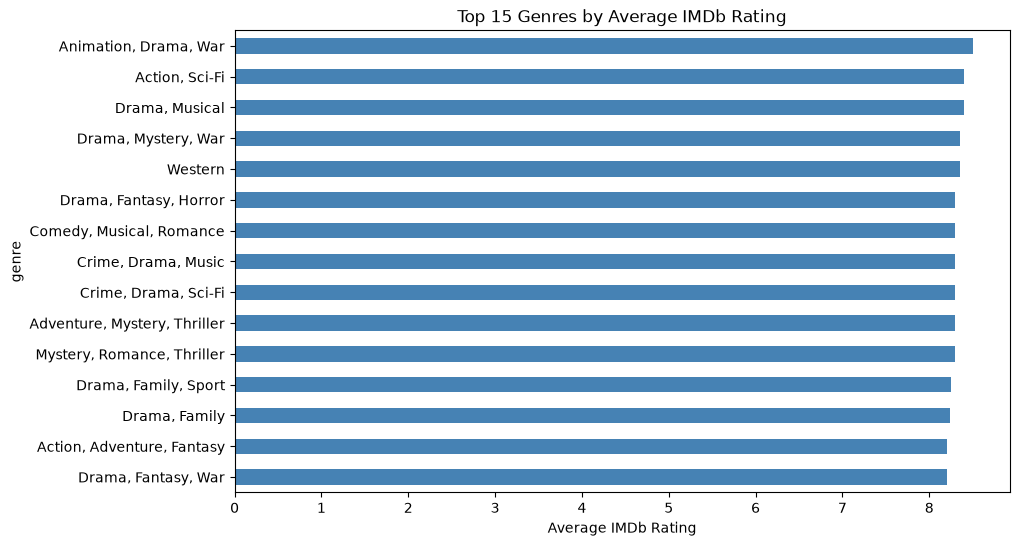

In [11]:
genre_avg = df.groupby('genre')['imdb_rating'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
genre_avg.plot(kind='barh', color='steelblue')
plt.xlabel('Average IMDb Rating')
plt.title('Top 15 Genres by Average IMDb Rating')
plt.gca().invert_yaxis()
plt.savefig('C:/imdb_project/genre_ratings.png', dpi=300, bbox_inches='tight')
plt.show()

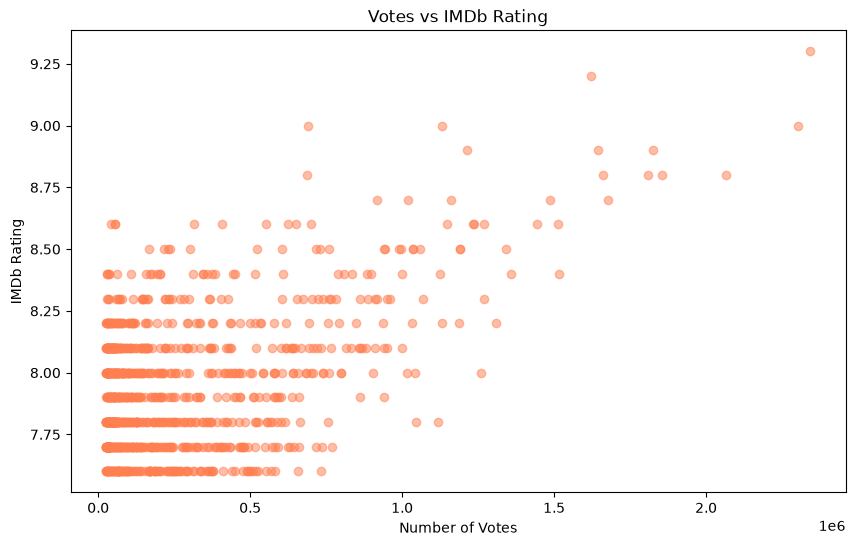

In [12]:
plt.figure(figsize=(10, 6))
plt.scatter(df['no_of_votes'], df['imdb_rating'], alpha=0.5, color='coral')
plt.xlabel('Number of Votes')
plt.ylabel('IMDb Rating')
plt.title('Votes vs IMDb Rating')
plt.savefig('C:/imdb_project/votes_vs_rating.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_28308\4287988026.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  genre_avg = pd.read_sql(query, conn)


<Axes: ylabel='genre'>

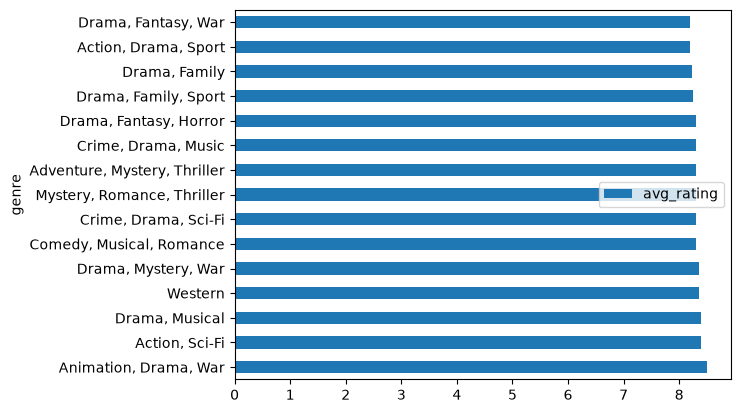

In [5]:
query = """
SELECT genre, AVG(imdb_rating) AS avg_rating
FROM imdb
GROUP BY genre
ORDER BY avg_rating DESC
LIMIT 15;
"""
genre_avg = pd.read_sql(query, conn)
genre_avg.plot(kind='barh', x='genre', y='avg_rating')

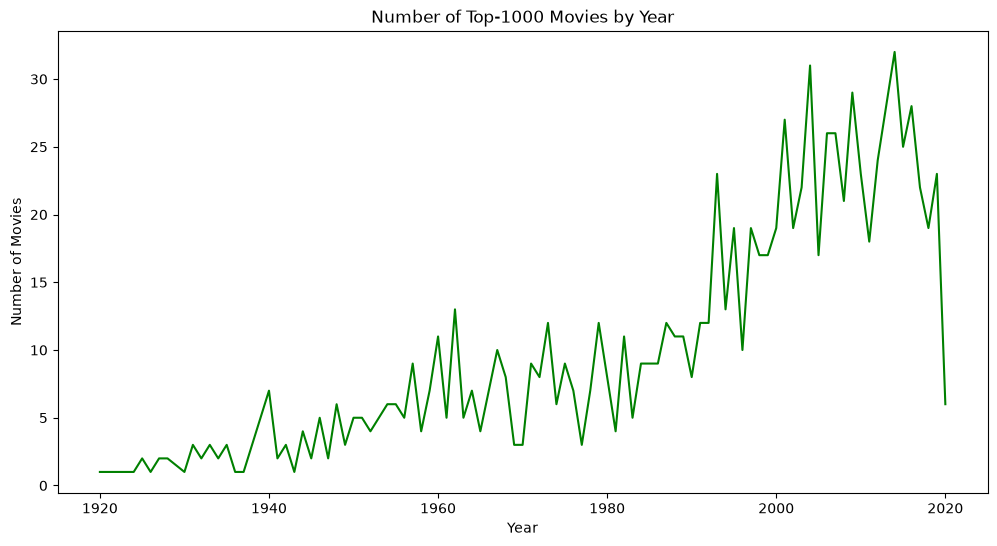

In [13]:
df['year_num'] = pd.to_numeric(df['released_year'], errors='coerce')
year_counts = df['year_num'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
plt.plot(year_counts.index, year_counts.values, color='green')
plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.title('Number of Top-1000 Movies by Year')
plt.savefig('C:/imdb_project/movies_by_year.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_5312\1853180313.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  top_directors = pd.read_sql(query, conn)


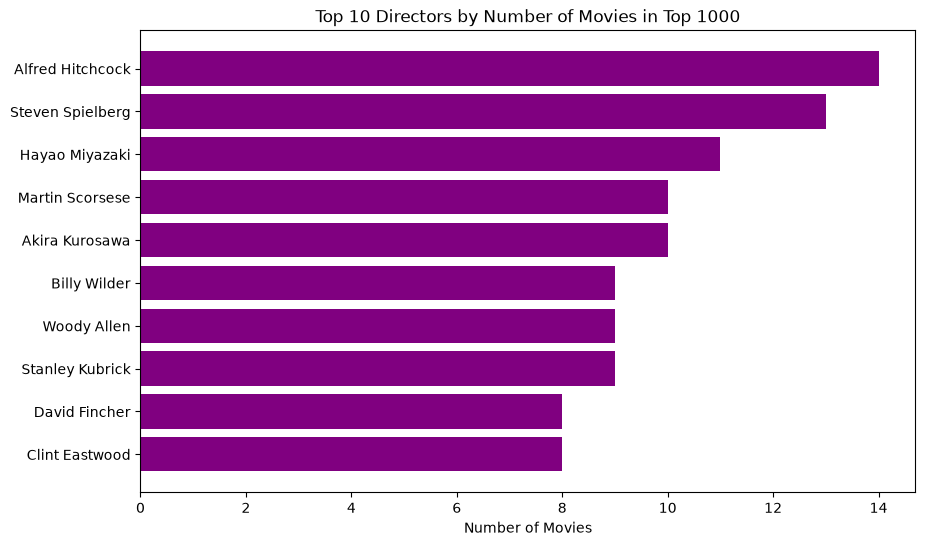

In [16]:
query = """
SELECT director, COUNT(*) AS movies_count
FROM imdb
GROUP BY director
HAVING COUNT(*) >= 3
ORDER BY movies_count DESC
LIMIT 10;
"""
top_directors = pd.read_sql(query, conn)

plt.figure(figsize=(10, 6))
plt.barh(top_directors['director'], top_directors['movies_count'], color='purple')
plt.xlabel('Number of Movies')
plt.title('Top 10 Directors by Number of Movies in Top 1000')
plt.gca().invert_yaxis()
plt.savefig('C:/imdb_project/top_10_directors.png', dpi=300, bbox_inches='tight')
plt.show()


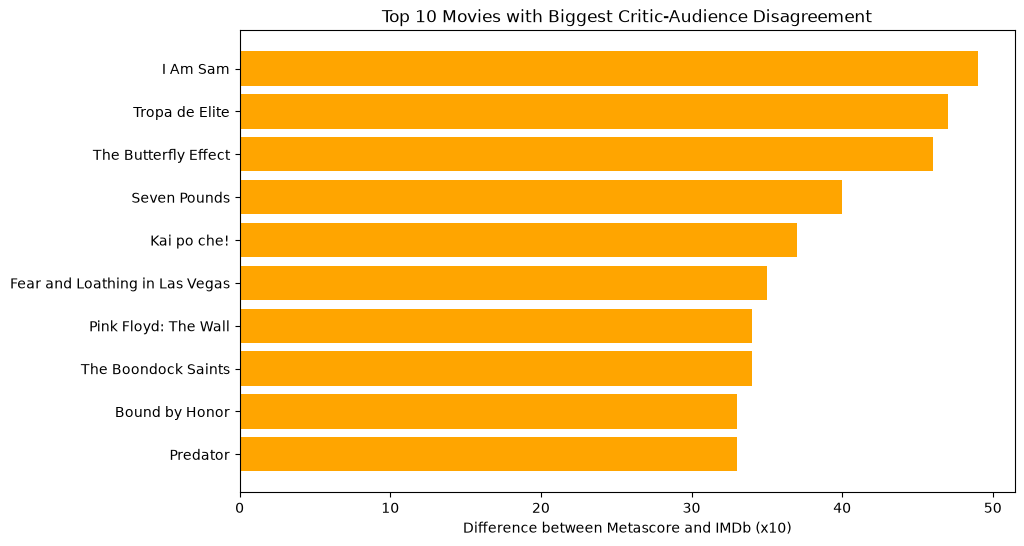

In [15]:
df['meta_score'] = pd.to_numeric(df['meta_score'], errors='coerce')
df['diff'] = abs(df['imdb_rating'] * 10 - df['meta_score'])

top_diff = df.dropna(subset=['diff']).nlargest(10, 'diff')

plt.figure(figsize=(10, 6))
plt.barh(top_diff['series_title'], top_diff['diff'], color='orange')
plt.xlabel('Difference between Metascore and IMDb (x10)')
plt.title('Top 10 Movies with Biggest Critic-Audience Disagreement')
plt.gca().invert_yaxis()
plt.savefig('C:/imdb_project/biggest_disagreement.png', dpi=300, bbox_inches='tight')
plt.show()

In [8]:
plt.savefig('genre_ratings.png', dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [9]:
plt.savefig('C:/imdb_project/genre_ratings.png', dpi=300, bbox_inches='tight')
plt.show()


<Figure size 640x480 with 0 Axes>

In [10]:
plt.savefig('C:/imdb_project/genre_ratings.png', dpi=300, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

In [6]:
correlation = df['imdb_rating'].corr(df['no_of_votes'])
print(f"Correlation between IMDb rating and number of votes: {correlation:.3f}")

Correlation between IMDb rating and number of votes: 0.495
